# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [4]:
# Load Dataset

# Load the COMPAS dataset used in the original R script
# Using raw GitHub URL to ensure reproducibility

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

raw_data.shape

(7214, 53)

In [5]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [6]:
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Select Relevant Variables
selected_cols = [
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
]

df = raw_data[selected_cols].copy()

# Data Filtering
df = df[
    df["days_b_screening_arrest"].between(-30, 30) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
].copy()

# Data Type Conversion
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

categorical_cols = [col for col in df.columns if col not in numeric_vars + datetime_vars]
for col in categorical_cols:
    df[col] = df[col].astype("category")

# Create derived categorical variables
df["crime_factor"] = df["c_charge_degree"].astype("category")
df["age_factor"] = df["age_cat"].astype("category")
df["race_factor"] = df["race"].astype("category")
df["gender_factor"] = df["sex"].astype("category")
df["score_factor"] = np.where(df["score_text"] != "Low", "HighScore", "LowScore")
df["score_factor"] = df["score_factor"].astype("category")

df.shape[0]

6172

In [7]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

At this point, all cleaning and transformation steps have been completed.

## COMPAS explainability pipeline

In [9]:
# Import Aidditional Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

In [10]:
# X and y from the cleaned COMPAS cohort
features = ["age", "priors_count", "days_b_screening_arrest", "c_charge_degree", "race", "age_cat", "sex"]
target = "two_year_recid"

X = df[features]
y = df[target].astype(int)

# Split the train and test data
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 7), Test: (1235, 7)


## Fit logistic regression and gradient-boosted tree

In [11]:
# Define numeric and categorical features
numeric_features = ["age", "priors_count", "days_b_screening_arrest"]
category_features = ["c_charge_degree", "race", "age_cat", "sex"]

preprocessor = ColumnTransformer([
("num", StandardScaler(), numeric_features),
("cat", OneHotEncoder(
handle_unknown="ignore"), category_features),
])

# Logistic regression (interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'days_b_screening_arrest']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['c_charge_degree', 'race',
                                                   'age_cat', 'sex'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

## Compare model performance by race

In [12]:
def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_eval = X.copy()
    X_eval["actual"] = y.values
    X_eval["pred"] = pipeline.predict(X)
    X_eval["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_eval.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"], labels=[0, 1]
        ).ravel()
        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3),
            "FNR": round(fn / (fn + tp), 3),
            "AUC": round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3),
        })
    return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))
print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.696  0.316  0.294  0.749
2         Caucasian  427     0.670  0.162  0.609  0.671
3          Hispanic   94     0.628  0.102  0.667  0.618
5             Other   65     0.785  0.085  0.556  0.730
1             Asian    7     0.857  0.000  1.000  1.000
4   Native American    1     1.000  0.000    NaN    NaN

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.683  0.349  0.288  0.733
2         Caucasian  427     0.703  0.139  0.559  0.692
3          Hispanic   94     0.649  0.143  0.578  0.630
5             Other   65     0.723  0.085  0.778  0.638
1             Asian    7     0.714  0.167  1.000  0.833
4   Native American    1     1.000  0.000    NaN    NaN


/tmp/ipykernel_1492/4155660422.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, gdf in X_eval.groupby(group_col):
/tmp/ipykernel_1492/4155660422.py:17: RuntimeWarning: invalid value encountered in scalar divide
  "FNR": round(fn / (fn + tp), 3),
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/tmp/ipykernel_1492/4155660422.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, gdf in X_eval.groupby(group_col):
/tmp/ipykernel_1492/4155660422.py:

## LIME explanations: four selected defendants

Focus on four defendants: the highest and lowest risk defendants in the African-American and Caucasian groups.

In [13]:
# Install lime
!pip install lime   # Run once if lime is not installed
from lime.lime_tabular import LimeTabularExplainer

X_train_enc = preprocessor.fit_transform(X_train)

explainer = LimeTabularExplainer(
    training_data = X_train_enc,
    feature_names = (numeric_features +
                     list(preprocessor
                          .named_transformers_["cat"]
                          .get_feature_names_out(category_features))),
    class_names = ["No Recid", "Recid"],
    mode = "classification",
    discretize_continuous = True,
    random_state = 42
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 18.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=cdddd06dcef853a8fc93b16449be09e18f22f54ee38eb4b5de5a74df99c7ed43
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [14]:
# Select two Black and two White defendants with highest and lowest predicted risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

aa_high_idx = X_test_copy[
    X_test_copy["race"] == "African-American"
].sort_values("pred_prob", ascending=False).index[0]

aa_low_idx = X_test_copy[
    X_test_copy["race"] == "African-American"
].sort_values("pred_prob").index[0]

white_high_idx = X_test_copy[
    X_test_copy["race"] == "Caucasian"
].sort_values("pred_prob", ascending=False).index[0]

white_low_idx = X_test_copy[
    X_test_copy["race"] == "Caucasian"
].sort_values("pred_prob").index[0]

In [15]:
# Generate and display LIME explanations
for label, idx in [("African-American highest-risk defendant", aa_high_idx),
                   ("African-American lowest-risk defendant", aa_low_idx),
                   ("Caucasian highest-risk defendant", white_high_idx),
                   ("Caucasian lowest-risk defendant", white_low_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
        data_row = row_enc[0],
        predict_fn = gbt_pipeline["classifier"].predict_proba,
        num_features = 6
    )

    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")


 LIME: African-American highest-risk defendant 
Predicted probability: 0.997
 days_b_screening_arrest > 0.15           +0.3751
 age <= -0.81                             +0.1834
 race_Asian <= 0.00                       +0.1676
 race_Other <= 0.00                       +0.0647
 -0.48 < priors_count <= 0.16             -0.0545
 sex_Female <= 0.00                       +0.0533

 LIME: African-American lowest-risk defendant 
Predicted probability: 0.030
 days_b_screening_arrest <= 0.15          -0.3865
 -0.69 < priors_count <= -0.48            -0.1732
 -0.81 < age <= -0.29                     +0.0562
 race_Other <= 0.00                       +0.0444
 sex_Female <= 0.00                       +0.0397
 c_charge_degree_M <= 0.00                +0.0237

 LIME: Caucasian highest-risk defendant 
Predicted probability: 0.991
 days_b_screening_arrest > 0.15           +0.3785
 age <= -0.81                             +0.1817
 -0.69 < priors_count <= -0.48            -0.1794
 race_Asian <= 0.00     

In a few cases, the feature ranking also does not line up with what seen in SHAP.

## SHAP beeswarm and waterfall

In [16]:
# Install shap
# !pip install shap # Run once if shap is not installed
import shap
import matplotlib.pyplot as plt

X_test_enc = preprocessor.transform(X_test)
feat_names = (numeric_features +
              list(preprocessor
                   .named_transformers_["cat"]
                   .get_feature_names_out(category_features)))

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)

shap_values = explainer_shap(X_test_enc, check_additivity=False)

 94%|=================== | 1156/1235 [00:12<00:00]       

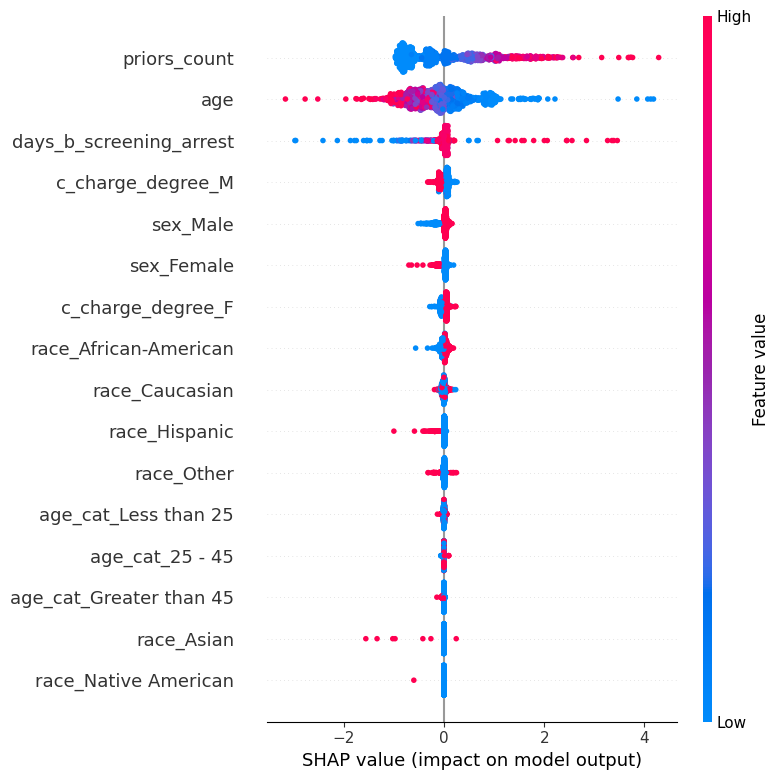

In [17]:
# Global beeswarm
shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names)

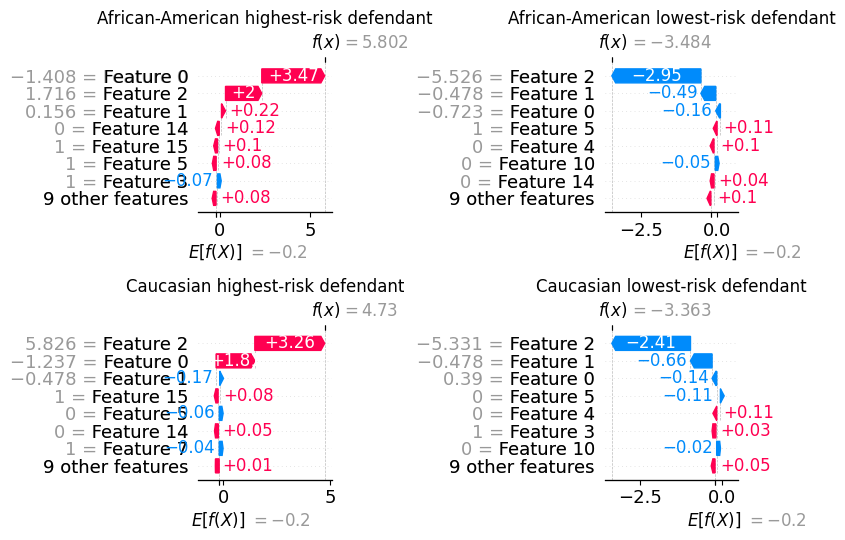

In [18]:
# Waterfall: four defendants
aa_high_loc = X_test.index.get_loc(aa_high_idx)
aa_low_loc = X_test.index.get_loc(aa_low_idx)
white_high_loc = X_test.index.get_loc(white_high_idx)
white_low_loc = X_test.index.get_loc(white_low_idx)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, loc, label in [
    (axes[0, 0], aa_high_loc, "African-American highest-risk defendant"),
    (axes[0, 1], aa_low_loc, "African-American lowest-risk defendant"),
    (axes[1, 0], white_high_loc, "Caucasian highest-risk defendant"),
    (axes[1, 1], white_low_loc, "Caucasian lowest-risk defendant")
]:
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc],
                        max_display=8,
                        show=False)
    ax.set_title(label)

plt.tight_layout()
plt.show()

The SHAP plots keep coming back to the same variables. Priors_count and age show up near the top in the beeswarm plot almost every time. In the waterfall plots, those two usually account for most of the change in a single prediction, sometimes taking up a large share.

## Counterfactuals with DiCE

In [20]:
# Install dice-ml
!pip install dice-ml  # Run once if dice-ml is not installed
import dice_ml
from dice_ml import Dice

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.9 MB/s eta 0:00:00


In [22]:
# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
    dataframe = pd.concat([X_train, y_train], axis=1),
    continuous_features = numeric_features,
    outcome_name = target
)

dice_model = dice_ml.Model(
    model = gbt_pipeline,
    backend = "sklearn",
    model_type = "classifier"
)
exp_dice = Dice(dice_data, dice_model, method="random")

for label, idx in [("African-American highest-risk defendant", aa_high_idx),
                   ("African-American lowest-risk defendant", aa_low_idx),
                   ("Caucasian highest-risk defendant", white_high_idx),
                   ("Caucasian lowest-risk defendant", white_low_idx)]:

    query = X_test.loc[[idx]]
    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs = 3,
        desired_class = "opposite",
        permitted_range = {"age" : [18, 70],
                           "priors_count" : [0, 38]},
        features_to_vary = ["age", "priors_count", "c_charge_degree"]
    )
    print(f"\n DiCE counterfactuals: {label} ")
    cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  5.40it/s]


 DiCE counterfactuals: African-American highest-risk defendant 
Query instance (original outcome : 1)


,age,priors_count,days_b_screening_arrest,c_charge_degree,race,age_cat,sex,two_year_recid
0,18,4,7.0,F,African-American,Less than 25,Male,1



Diverse Counterfactual set (new outcome: 0)


,age,priors_count,days_b_screening_arrest,c_charge_degree,race,age_cat,sex,two_year_recid
0,70,2,-,-,-,-,-,0
1,68,2,-,-,-,-,-,0
2,70,-,-,M,-,-,-,0


...

100%|██████████| 1/1 [00:00<00:00,  8.83it/s]


 DiCE counterfactuals: Caucasian lowest-risk defendant 
Query instance (original outcome : 0)


,age,priors_count,days_b_screening_arrest,c_charge_degree,race,age_cat,sex,two_year_recid
0,39,1,-29.0,F,Caucasian,25 - 45,Male,0



Diverse Counterfactual set (new outcome: 1)


,age,priors_count,days_b_screening_arrest,c_charge_degree,race,age_cat,sex,two_year_recid
0,63,10,-,-,-,-,-,1
1,-,19,-,M,-,-,-,1
2,53,7,-,-,-,-,-,1


Looking across the counterfactual outputs, a few patterns stand out

Across the generated counterfactuals, priors_count and c_charge_degree are the features that get adjusted most often. In a lot of cases, the change is small, sometimes just a difference of one or two prior offenses, and that is enough to shift the prediction. Age shows up as well, but it behaves differently. Some changes are minor, but others are not. There are several cases where the prediction only flips when age moves from the early 20s to something closer to 60.

Race and sex were held fixed throughout the analysis, so none of the counterfactuals attempt to change them. That makes the results easier to read, but it also means the space of possible changes is already restricted.

## Overall Analysis

Based on the results from LIME, SHAP, and DiCE, the same variables keep appearing. Age, priors_count, and days_b_screening_arrest show up in most of the explanations. After going through several cases, the pattern becomes clear. Higher priors_count with lower age is often linked to higher predicted risk. Lower priors_count and older age appear more often in lower-risk cases.

In the LIME results, these variables usually carry most of the weight. Some explanations are very clear. Others are less stable. There are cases where one-hot encoded variables, including race or sex indicators, show up with noticeable weight.

The SHAP outputs point to a similar set of variables. The beeswarm plot keeps highlighting priors_count and age. The waterfall plots show how each feature contributes to the prediction in individual cases. These features tend to account for most of the movement in the prediction, sometimes contributing the largest positive or negative shifts. The ordering is more consistent from case to case, and the direction of the effect is easier to follow.

The counterfactual results highlight the same variables again. Changes in priors_count and c_charge_degree often shift the prediction. Age also appears frequently. In several cases, the model only flips when age moves from the early 20s to around 60. In other cases, the change is much smaller.

Across methods, the same features keep coming up. The details shift from one method to another, but the core variables do not.

## Governance Memo

To: Court Auditor
From: Jessie Hsu
Subject: Governance Assessment of COMPAS Replacement Model
Date: March , 2026

The model is driven by just a few variables, mainly age, priors_count, and days_b_screening_arrest. Looking at the cases, people with priors_count above 3 and age under 25 almost always end up in the high-risk group, while older individuals with fewer priors are pushed the other way. This makes the model easy to read, but it means the model is leaning hard on a narrow set of signals, and if those signals carry bias, the model will carry it too.

SHAP and LIME mostly point to the same features, but sometimes they do not behave the same way.. SHAP is fairly consistent and keeps highlighting age and prior history. LIME is less stable. In a few cases, it puts noticeable weight on race or sex indicators, even when those do not look like the main drivers. If the explanation changes depending on the tool, it becomes harder to justify the result in a real decision setting.

The counterfactual outputs are hard to defend. Some of them require pushing age from the early 20s to around 60 just to flip the prediction. That is technically valid, but not something anyone can act on. Race and sex were kept fixed throughout, but that does not fix the bigger issue. The model is not giving much useful guidance at the individual level.

I also see differences across racial groups. African-American defendants are more often assigned higher predicted risk than Caucasian defendants with similar profiles. At the same time, there are very few cases from some groups, so those results are unstable and I would not rely on them.

Recomendation:

Check subgroup error rates regularly. Look at SHAP and LIME side by side before accepting any explanation. Review variables that could act as proxies. Do not treat model output as sufficient on its own.
